# pyDySP Demo

This notebook demonstrates the core functionality of **pyDySP** using synthetic data.

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

import pydysp

print("pyDySP version:", pydysp.__version__)

pyDySP version: 0.2.0


## Artificial data generation

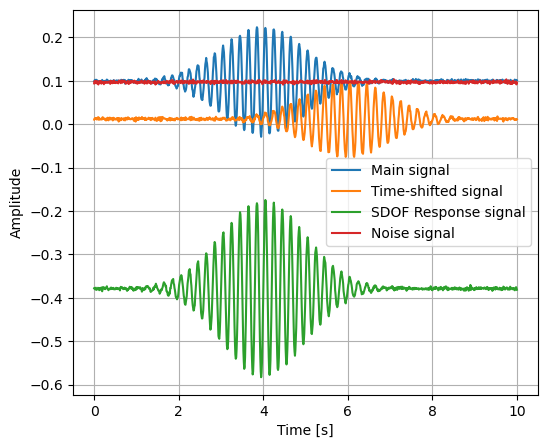

In [2]:
# Generate time vector
t = np.linspace(0, 10, 1001)

# Empty signal list
signals = []
legends = []

# Gaussian modulated sine wave
a0 = 0.5 / 4  # amplitude of the sine wave (with calibration factor 4.0)
f0 = 5  # frequency of the sine wave
t0 = 4  # center of the Gaussian envelope
dur = 6  # duration of the Gaussian envelope
sigma = dur / 2 / 3  # convert duration to standard deviation (+- 3 sigma)

# Time shifted copy
dt = 2  # time shift
a_ratio = 0.7  # amplitude ratio

# SDOF properties
ksi = 0.05
f_sdof = 8
omega = 2 * np.pi * f_sdof

# Offset and noise level
offset = 0.2  # vertical offset (random)
noise = 0.002  # noise level (random)
np.random.seed(42)  # for reproducibility

# Generate main signal (gaussian-modulated sine wave)
signal1 = a0 * np.sin(2 * np.pi * f0 * t) * np.exp(-((t - t0) ** 2) / (2 * sigma**2))
signals.append(signal1 + offset * np.random.randn() + noise * np.random.randn(len(t)))
legends.append("Main signal")

# Generate time-shifted signal
signal2 = (
    a_ratio
    * a0
    * np.sin(2 * np.pi * f0 * (t - dt))
    * np.exp(-((t - t0 - dt) ** 2) / (2 * sigma**2))
)
signals.append(signal2 + offset * np.random.randn() + noise * np.random.randn(len(t)))
legends.append("Time-shifted signal")

# Generate SDOF Response signal
a_in = sp.interpolate.interp1d(t, signal1)


def sdof_ode(t, y):
    u, v = y
    a = -a_in(t) - 2.0 * ksi * omega * v - (omega**2) * u
    return [v, a]


sol = sp.integrate.solve_ivp(
    sdof_ode, (t[0], t[-1]), [0.0, 0.0], t_eval=t, method="RK45"
)
u = sol.y[0]
v = sol.y[1]
signal3 = -2.0 * ksi * omega * v - (omega**2) * u
signals.append(signal3 + offset * np.random.randn() + noise * np.random.randn(len(t)))
legends.append("SDOF Response signal")

# Generate noise signal
signal4 = np.zeros_like(t)
signals.append(signal4 + offset * np.random.randn() + noise * np.random.randn(len(t)))
legends.append("Noise signal")

# Plot signals
signals = np.array(signals).T
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(t, signals)
ax.legend(legends)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.grid(True)
plt.show()

## Building `Channel` and `Test` objects

In [3]:
# Create pydysp Channels
n_channels = signals.shape[1]
channels = [
    pydysp.Channel(
        data=signals[:, i],
        time=t,
        name_user=f"Channel {i+1}",
        description_long=legends[i],
        quantity="acceleration",
        units="g",
        tags={"synthetic"},
        calibration_factor=4.0,
    )
    for i in range(n_channels)
]

# Create pydysp Test
test = pydysp.Test.from_channels(
    name="Demo test",
    channels=channels,
    description="Artificial data for demonstration purposes",
)

# Print test info
print(test.info())

Test: Demo test
  Description : Artificial data for demonstration purposes
  Channels    : 4
  Timesteps   : 1001
  Duration    : 10 s
  Sampling    : dt=0.01 s, fs=100 Hz

|   idx | name_user   | name_input   | quantity     | units   | tags                     |
|-------|-------------|--------------|--------------|---------|--------------------------|
|     0 | Channel 1   | -            | acceleration | g       | q:acceleration,synthetic |
|     1 | Channel 2   | -            | acceleration | g       | q:acceleration,synthetic |
|     2 | Channel 3   | -            | acceleration | g       | q:acceleration,synthetic |
|     3 | Channel 4   | -            | acceleration | g       | q:acceleration,synthetic |


## Working with a single `Channel`

### Calling a channel

In [4]:
# Different ways to select a channel
ch1a = test[0]
ch1b = test.channel[0]
ch1c = test.channels[0]
ch1d = test["Channel 1"]

# Confirm they are the same
print(ch1a.name_user)
print(ch1b.name_user)
print(ch1c.name_user)
print(ch1d.name_user)

Channel 1
Channel 1
Channel 1
Channel 1


### Processing channel data

Note that processing only happens when asking for the channel data.

In [5]:
# Processing channel data
ch1 = test[0].drift_corrected(points=20).filtered(btype="lowpass", fc=20, order=2)

# Print processed channel info
print(ch1.info())

Channel: Channel 1
------------------
Length: 1001 samples
Sampling frequency: fs = 100 Hz
Timestep: dt = 0.01 s
Start time: t0 = 0.0 s

Physical meaning & calibration:
  Quantity: acceleration
  Units: g
  Calibration factor: 4.0 g/raw

Naming / labels:
  User name: Channel 1
  Legend label: Channel 1
  Axis label: Channel 1 [g]
  Description: Main signal

Tags:
  drift_corrected
  filtered
  q:acceleration
  synthetic

Processing:
  Drift params: {'points': 20}
  Filter params: {'btype': 'lowpass', 'fc': 20, 'order': 2}
  Notes:
    - Drift params set: {'points': 20}
    - Filter params set: {'btype': 'lowpass', 'fc': 20, 'order': 2}


In [6]:
# Get time and acceleration
time, accel = ch1.xy()

# Print
print("time:", time)
print("accel:", accel)

time: [ 0.    0.01  0.02 ...  9.98  9.99 10.  ]
accel: [-9.27723629e-05  5.78716322e-03  6.85420791e-03 ...  4.81383994e-03
  7.56848417e-03  8.41124825e-03]


### Plotting

Timehistory Peak: (3.85, 0.500902296316157)
Fourier Peak: (4.98046875, 61.790988617731834)


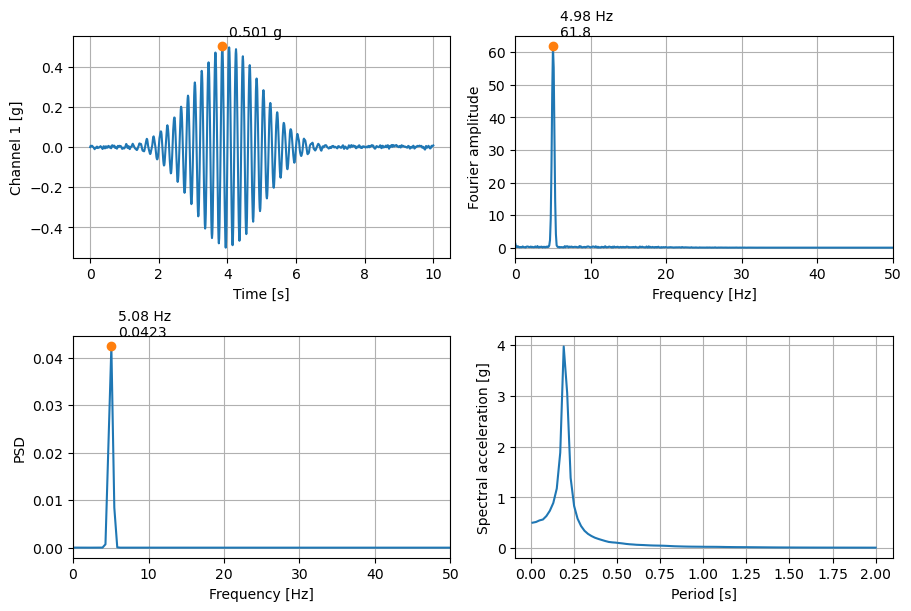

In [7]:
# Plot channel data
fig, axes = plt.subplots(2, 2, figsize=(9, 6), layout="constrained")

ch1.plot(ax=axes[0, 0])
ch1.plot_fourier(ax=axes[0, 1])
ch1.plot_psd(ax=axes[1, 0])
ch1.plot_response_spectrum(periods=np.linspace(0.01, 2.0, 100), ax=axes[1, 1])

# Helper function for peak annotation
pydysp.annotate_peak(channel=ch1, ax=axes[0, 0], peak="abs")
pydysp.annotate_peak(channel=ch1, ax=axes[0, 1], plot="fourier")
pydysp.annotate_peak(channel=ch1, ax=axes[1, 0], plot="psd")

# Printing relevant peaks
print("Timehistory Peak:", ch1.max_abs())
print("Fourier Peak:", ch1.fourier_peak())

### Arias intensity & automatic trimming

Original duration: 10.0
Trimmed duration:  3.81


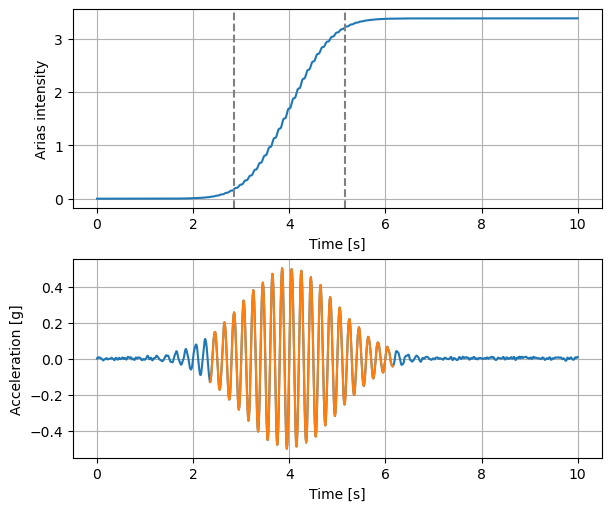

In [8]:
ch1_trimmed = ch1.trim_by_arias(
    lower=0.05, upper=0.95, buffer_before=0.5, buffer_after=1
)

# Plot original and trimmed signals
fig, axes = plt.subplots(2, 1, figsize=(6, 5), layout="constrained")
ch1.plot_arias(ax=axes[0], show_window=True)
ch1.plot(ax=axes[1])
ch1_trimmed.plot(ax=axes[1], include_kind=True)

# Print Arias Intensity and durations

print("Original duration:", ch1.duration)
print("Trimmed duration: ", ch1_trimmed.duration)

## Working at `Test` level

### Batch Processing

In [9]:
test = test.drift_corrected(points=200).filtered(btype="lowpass", fc=20, order=2)

test_trimmed = test.trimmed_by_arias(
    ref="Channel 1", lower=0.05, upper=0.95, buffer_before=0.5, buffer_after=1
)

print("Original duration:", test.duration)
print("Trimmed duration:  ", test_trimmed.duration)

Original duration: 10.0
Trimmed duration:   3.81


### Batch Plotting

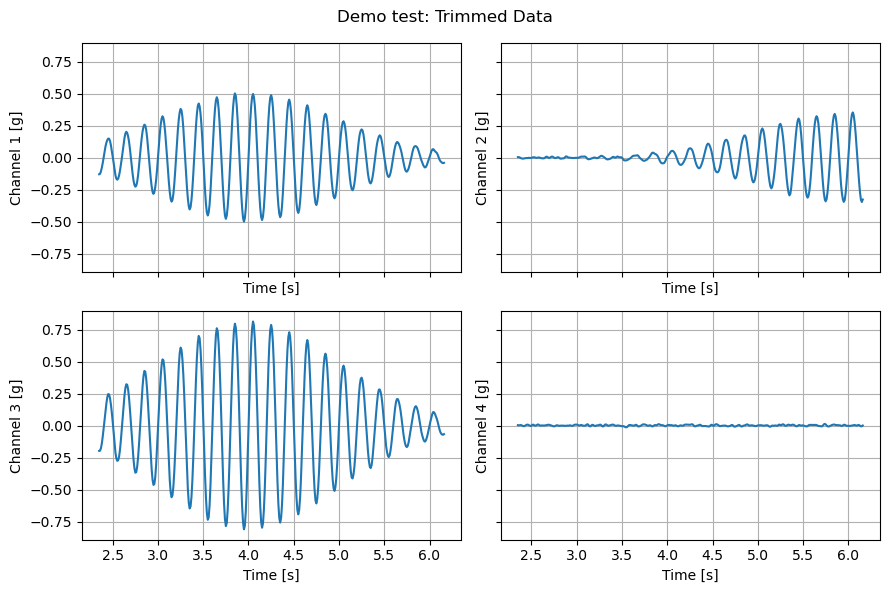

In [10]:
fig, ax = test_trimmed.plot_channels(
    selector=[0, 1, 2, "Channel 4"],
    ncols=2,
    plot_type="timehistory",
    title_suffix="Trimmed Data",
)
fig.set_size_inches(9, 6)

## Cross-channel analysis

(-2.5, 20.0)

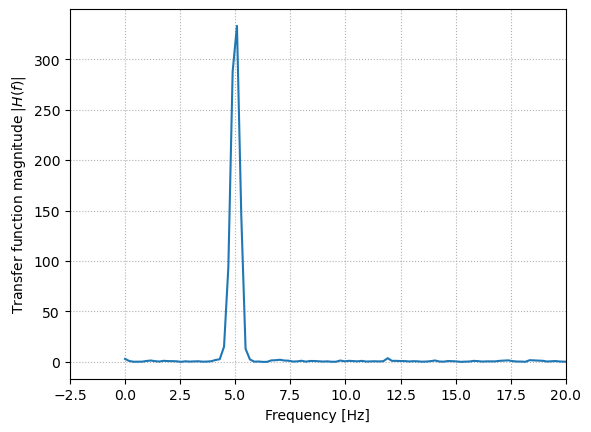

In [11]:
# Transfer function
ax = test.plot_transfer_function(
    x="Channel 4", y="Channel 1", kind="H1", tf_kwargs={"nperseg": 512}
)
ax.set_xscale("linear")
ax.set_xlim(right=20)

# try:
#    ema_model = test_proc.ema_model(
#        input=input_ch,
#        outputs=[output_ch],
#        kind="H1",
#        lower=1.0,
#        upper=50.0,
#    )
#    print(ema_model)
# except ImportError as e:
#    print("sdypy not installed; skipping EMA example.")

In [12]:
delay = test.time_delay(x="Channel 1", y="Channel 2")
print("Estimated time delay [s]:", delay)

Estimated time delay [s]: 2.0


### Channel health report

In [13]:
print(test.channel_health())

|   idx | name      |   peak |     rms |   crest |   t_start |   t_end |   dur | rms_pre   | snr_pre   | status        |
|-------|-----------|--------|---------|---------|-----------|---------|-------|-----------|-----------|---------------|
|     0 | Channel 1 |  0.501 |   0.148 |    3.39 |      1.63 |    6.37 |  4.74 | 0.00783   | 27.4      | ok            |
|     1 | Channel 2 |  0.352 |   0.104 |    3.39 |      3.52 |    8.46 |  4.94 | 0.00491   | 30        | ok            |
|     2 | Channel 3 |  0.814 |   0.241 |    3.38 |      1.64 |    6.46 |  4.82 | 0.0121    | 28.7      | ok            |
|     3 | Channel 4 | 0.0171 | 0.00468 |    3.65 |         0 |      10 |    10 | -         | -         | weak response |


## Saving to `csv` and reloading

In [14]:
test.to_csv(filename="../data/demo_data.csv", overwrite=True)
test.channel_info_to_csv(filename="../data/demo_channel_info.csv", overwrite=True)

reloaded_test = pydysp.Test.from_csv(
    "../data/demo_data.csv", name="ProcessedFromCSV"
).with_channel_info_from_csv(
    "../data/demo_channel_info.csv",
)
print(reloaded_test.info())
print("\n" + "-" * 80 + "\n")
print(reloaded_test.channel[1].info())

Test: ProcessedFromCSV
  Source file : ../data/demo_data.csv
  Channels    : 4
  Timesteps   : 1001
  Duration    : 10 s
  Sampling    : dt=0.01 s, fs=100 Hz
  Test tags   : csv
  Meta keys   : csv_header, csv_n_channels, csv_n_samples

|   idx | name_user   | name_input    | quantity   | units   | tags   |
|-------|-------------|---------------|------------|---------|--------|
|     0 | Channel 1   | Channel 1 [g] | -          | -       | -      |
|     1 | Channel 2   | Channel 2 [g] | -          | -       | -      |
|     2 | Channel 3   | Channel 3 [g] | -          | -       | -      |
|     3 | Channel 4   | Channel 4 [g] | -          | -       | -      |

--------------------------------------------------------------------------------

Channel: Channel 2
------------------
Length: 1001 samples
Sampling frequency: fs = 100 Hz
Timestep: dt = 0.01 s
Start time: t0 = 0.0 s

Naming / labels:
  Input name: Channel 2 [g]
  User name: Channel 2
  Legend label: Channel 2
  Axis label: Cha